
# Klasifikasi Status Meteorite dengan TabTransformer sekaligus Membandingkan dengan metode lainnya

**Dataset:** NASA Meteorite Landings  
**Target:** `fall` → `Fell` / `Found`  
**Metode:** TabTransformer

Pipeline:
1. Load dataset
2. Data understanding
3. Cleaning & preprocessing
4. Train/test split
5. TabTransformer
6. Training
7. Evaluation
8. Confusion Matrix & ROC-AUC


In [25]:
# Import library
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve,
    precision_recall_curve, average_precision_score
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## 1. Upload Dataset

In [26]:
file_name = 'meteorite-landings.csv'
print("File:", file_name)


File: meteorite-landings.csv


In [27]:

# Baca CSV
df = pd.read_csv(file_name)

print("Shape:", df.shape)
display(df.head())


Shape: (45716, 10)


,name,id,nametype,recclass,mass,fall,year,reclat,reclong,GeoLocation
0,Aachen,1,Valid,L5,21.0,Fell,1880.0,50.77500,6.08333,"(50.775000, 6.083330)"
1,Aarhus,2,Valid,H6,720.0,Fell,1951.0,56.18333,10.23333,"(56.183330, 10.233330)"
2,Abee,6,Valid,EH4,107000.0,Fell,1952.0,54.21667,-113.00000,"(54.216670, -113.000000)"
3,Acapulco,10,Valid,Acapulcoite,1914.0,Fell,1976.0,16.88333,-99.90000,"(16.883330, -99.900000)"
4,Achiras,370,Valid,L6,780.0,Fell,1902.0,-33.16667,-64.95000,"(-33.166670, -64.950000)"


## 2. Data Understanding

In [28]:

print("Informasi dataset:")
df.info()

print("\nMissing values:")
display(df.isnull().sum().sort_values(ascending=False))

print("\nDuplicate:", df.duplicated().sum())

print("\nNilai target:")
display(df["fall"].value_counts(dropna=False))


Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45716 entries, 0 to 45715
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   name         45716 non-null  object 
 1   id           45716 non-null  int64  
 2   nametype     45716 non-null  object 
 3   recclass     45716 non-null  object 
 4   mass         45585 non-null  float64
 5   fall         45716 non-null  object 
 6   year         45428 non-null  float64
 7   reclat       38401 non-null  float64
 8   reclong      38401 non-null  float64
 9   GeoLocation  38401 non-null  object 
dtypes: float64(4), int64(1), object(5)
memory usage: 3.5+ MB

Missing values:


GeoLocation    7315
reclong        7315
reclat         7315
year            288
mass            131
name              0
id                0
fall              0
nametype          0
recclass          0
dtype: int64


Duplicate: 0

Nilai target:


fall
Found    44609
Fell      1107
Name: count, dtype: int64

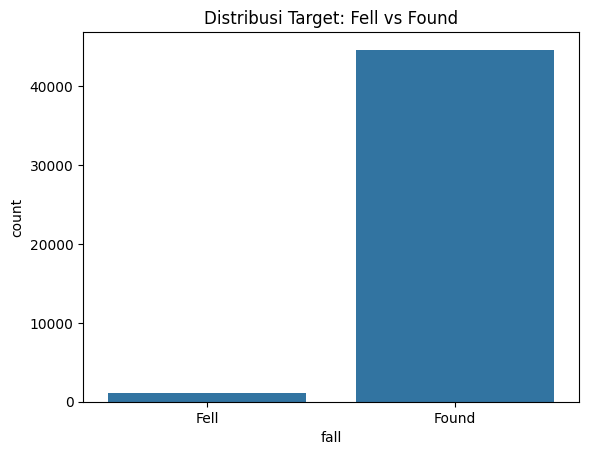

In [29]:

# Distribusi target
sns.countplot(data=df, x="fall")
plt.title("Distribusi Target: Fell vs Found")
plt.show()



## 3. Cleaning

Fitur yang digunakan:

- `mass`
- `year`
- `reclat`
- `reclong`
- `recclass`
- `nametype`

Target:

- `fall`


In [30]:
# Pastikan nama kolom tersedia
required_cols = ["mass", "year", "reclat", "reclong", "recclass", "nametype", "fall"]

missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Kolom berikut tidak ditemukan: {missing_cols}")

data = df[required_cols].copy()

# Hanya gunakan target Fell/Found
data["fall"] = data["fall"].astype(str).str.strip().str.title()
data = data[data["fall"].isin(["Fell", "Found"])].copy()

# Konversi numerik
base_numeric = ["mass", "year", "reclat", "reclong"]
for col in base_numeric:
    data[col] = pd.to_numeric(data[col], errors="coerce")

# Kategori
categorical_cols = ["recclass", "nametype"]
for col in categorical_cols:
    data[col] = data[col].fillna("Unknown").astype(str).str.strip()

# ---------- Feature engineering ----------
# Missing indicator
data["mass_missing"] = data["mass"].isna().astype(int)
data["year_missing"] = data["year"].isna().astype(int)

# Koordinat (0,0) = placeholder, bukan lokasi asli
zero_coord = (data["reclat"] == 0) & (data["reclong"] == 0)
data.loc[zero_coord, ["reclat", "reclong"]] = np.nan
data["coord_missing"] = data["reclat"].isna().astype(int)

# Mass sangat skewed -> log
data["mass"] = np.log1p(data["mass"])

# Fitur lokasi turunan
data["abs_lat"] = data["reclat"].abs()
data["is_antarctica"] = (data["reclat"] < -60).astype(int)

# recclass langka -> "Other"
counts = data["recclass"].value_counts()
rare = counts[counts < 20].index
data["recclass"] = data["recclass"].where(~data["recclass"].isin(rare), "Other")

numeric_cols = ["mass", "year", "reclat", "reclong", "abs_lat",
                "mass_missing", "year_missing", "coord_missing", "is_antarctica"]
# -----------------------------------------

# Hapus duplicate
data = data.drop_duplicates().reset_index(drop=True)

print("Shape setelah cleaning:", data.shape)
display(data.head())

Shape setelah cleaning: (43112, 12)


,mass,year,reclat,reclong,recclass,nametype,fall,mass_missing,year_missing,coord_missing,abs_lat,is_antarctica
0,3.091042,1880.0,50.77500,6.08333,L5,Valid,Fell,0,0,0,50.77500,0
1,6.580639,1951.0,56.18333,10.23333,H6,Valid,Fell,0,0,0,56.18333,0
2,11.580593,1952.0,54.21667,-113.00000,Other,Valid,Fell,0,0,0,54.21667,0
3,7.557473,1976.0,16.88333,-99.90000,Acapulcoite,Valid,Fell,0,0,0,16.88333,0
4,6.660575,1902.0,-33.16667,-64.95000,L6,Valid,Fell,0,0,0,33.16667,0


In [31]:

# Statistik missing value setelah cleaning
display(data.isnull().sum())

# Distribusi target
display(data["fall"].value_counts())


mass                94
year               287
reclat           12542
reclong          12542
recclass             0
nametype             0
fall                 0
mass_missing         0
year_missing         0
coord_missing        0
abs_lat          12542
is_antarctica        0
dtype: int64

fall
Found    42005
Fell      1107
Name: count, dtype: int64


## 4. Train/Test Split

Split dilakukan **sebelum fitting scaler/imputer** agar preprocessing tidak mengalami data leakage.


In [32]:
X = data.drop(columns=["fall"])
y = (data["fall"] == "Fell").astype(np.float32)

# Test 20%
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

# Val 15% dari sisa train
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=SEED, stratify=y_train
)

print("Train:", X_train.shape)
print("Val  :", X_val.shape)
print("Test :", X_test.shape)

Train: (29315, 11)
Val  : (5174, 11)
Test : (8623, 11)


## 5. Preprocessing

In [33]:
# Imputer + scaler: fit hanya di train
num_imputer = SimpleImputer(strategy="median")
X_train_num = num_imputer.fit_transform(X_train[numeric_cols])
X_val_num   = num_imputer.transform(X_val[numeric_cols])
X_test_num  = num_imputer.transform(X_test[numeric_cols])

scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train_num)
X_val_num   = scaler.transform(X_val_num)
X_test_num  = scaler.transform(X_test_num)

# Encoding kategori (Unknown = 0, mapping dari train saja)
category_maps = {}
X_train_cat, X_val_cat, X_test_cat = [], [], []

for col in categorical_cols:
    train_values = X_train[col].fillna("Unknown").astype(str)
    val_values   = X_val[col].fillna("Unknown").astype(str)
    test_values  = X_test[col].fillna("Unknown").astype(str)

    categories = sorted(train_values.unique().tolist())
    mapping = {value: idx + 1 for idx, value in enumerate(categories)}
    category_maps[col] = mapping

    X_train_cat.append(train_values.map(mapping).fillna(0).astype(int).values)
    X_val_cat.append(val_values.map(mapping).fillna(0).astype(int).values)
    X_test_cat.append(test_values.map(mapping).fillna(0).astype(int).values)

X_train_cat = np.column_stack(X_train_cat)
X_val_cat   = np.column_stack(X_val_cat)
X_test_cat  = np.column_stack(X_test_cat)

print("Numerical train:", X_train_num.shape)
print("Categorical train:", X_train_cat.shape)
print("Category sizes:", {c: len(m) + 1 for c, m in category_maps.items()})

Numerical train: (29315, 9)
Categorical train: (29315, 2)
Category sizes: {'recclass': 107, 'nametype': 3}



## 6. PyTorch Dataset


In [34]:
class MeteoriteDataset(Dataset):
    def __init__(self, X_num, X_cat, y):
        self.X_num = torch.tensor(X_num, dtype=torch.float32)
        self.X_cat = torch.tensor(X_cat, dtype=torch.long)
        self.y = torch.tensor(np.asarray(y), dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X_num[idx], self.X_cat[idx], self.y[idx]
train_dataset = MeteoriteDataset(X_train_num, X_train_cat, y_train.values)
val_dataset   = MeteoriteDataset(X_val_num, X_val_cat, y_val.values)
test_dataset  = MeteoriteDataset(X_test_num, X_test_cat, y_test.values)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=256, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=256, shuffle=False)


## 7. TabTransformer

Arsitektur:

`Categorical Embedding → Transformer Encoder → Concatenate Numerical Features → MLP → Sigmoid`

Model menggunakan attention pada fitur kategorikal, sementara fitur numerik diproses sebagai fitur kontinu yang kemudian digabungkan dengan representasi hasil Transformer.


In [35]:
class TabTransformer(nn.Module):
    def __init__(
        self,
        categories,
        num_numeric,
        dim=32,
        depth=3,
        heads=4,
        attn_dropout=0.1,
        ff_dropout=0.1,
        mlp_hidden=64
    ):
        super().__init__()

        self.num_numeric = num_numeric
        self.dim = dim

        self.embeddings = nn.ModuleList([
            nn.Embedding(num_categories, dim)
            for num_categories in categories
        ])

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=dim,
            nhead=heads,
            dim_feedforward=dim * 4,
            dropout=attn_dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True
        )

        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)

        input_dim = dim * len(categories) + num_numeric

        self.mlp = nn.Sequential(
            nn.Linear(input_dim, mlp_hidden * 2),
            nn.ReLU(),
            nn.BatchNorm1d(mlp_hidden * 2),
            nn.Dropout(ff_dropout),

            nn.Linear(mlp_hidden * 2, mlp_hidden),
            nn.ReLU(),
            nn.BatchNorm1d(mlp_hidden),
            nn.Dropout(ff_dropout),

            nn.Linear(mlp_hidden, mlp_hidden // 2),
            nn.ReLU(),
            nn.Dropout(ff_dropout * 0.7),

            nn.Linear(mlp_hidden // 2, 1)
        )

    def forward(self, x_num, x_cat):
        embeddings = [emb(x_cat[:, i]) for i, emb in enumerate(self.embeddings)]
        x_cat = torch.stack(embeddings, dim=1)
        x_cat = self.transformer(x_cat)
        x_cat = x_cat.flatten(start_dim=1)
        x = torch.cat([x_cat, x_num], dim=1)
        return self.mlp(x).squeeze(1)

In [36]:
# Jumlah kategori masing-masing fitur
category_sizes = [
    len(category_maps[col]) + 1
    for col in categorical_cols
]

model = TabTransformer(
    categories=category_sizes,
    num_numeric=len(numeric_cols),
    dim=32, depth=3, heads=4,
    attn_dropout=0.30,
    ff_dropout=0.30,
    mlp_hidden=128      # coba 64 vs 128
).to(device)

print(model)

TabTransformer(
  (embeddings): ModuleList(
    (0): Embedding(107, 32)
    (1): Embedding(3, 32)
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
        )
        (linear1): Linear(in_features=32, out_features=128, bias=True)
        (dropout): Dropout(p=0.3, inplace=False)
        (linear2): Linear(in_features=128, out_features=32, bias=True)
        (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True, bias=True)
        (dropout1): Dropout(p=0.3, inplace=False)
        (dropout2): Dropout(p=0.3, inplace=False)
      )
    )
  )
  (mlp): Sequential(
    (0): Linear(in_features=73, out_features=256, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, 

C:\Users\LEGION\AppData\Local\Temp\ipykernel_30896\3272952443.py:33: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)


## 8. Training

In [37]:
# Class weighting untuk mengatasi class imbalance
class_counts = np.bincount(y_train.astype(int))

neg_count = class_counts[0]  # Found
pos_count = class_counts[1]  # Fell

base_weight = neg_count / max(pos_count, 1)

pos_weight = torch.tensor([np.sqrt(base_weight)], dtype=torch.float32, device=device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-5
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=3
)

print("Class counts:", class_counts)
print("Base weight:", base_weight)
print("Final positive weight:", pos_weight.item())

Class counts: [28562   753]
Base weight: 37.93094289508632
Final positive weight: 6.158810138702393


In [38]:
def evaluate_loss(model, loader):
    model.eval()
    total_loss = 0.0
    total_n = 0

    with torch.no_grad():
        for x_num, x_cat, y_batch in loader:
            x_num = x_num.to(device)
            x_cat = x_cat.to(device)
            y_batch = y_batch.to(device)

            logits = model(x_num, x_cat)
            loss = criterion(logits, y_batch)

            total_loss += loss.item() * len(y_batch)
            total_n += len(y_batch)

    return total_loss / total_n


EPOCHS = 100
patience = 15
best_val_loss = float("inf")
patience_counter = 0

history = {
    "train_loss": [],
    "val_loss": []
}

best_state = None

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    total_n = 0

    for x_num, x_cat, y_batch in train_loader:
        x_num = x_num.to(device)
        x_cat = x_cat.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        logits = model(x_num, x_cat)
        loss = criterion(logits, y_batch)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item() * len(y_batch)
        total_n += len(y_batch)

    train_loss = running_loss / total_n
    val_loss = evaluate_loss(model, val_loader)
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {
            k: v.detach().cpu().clone()
            for k, v in model.state_dict().items()
        }
        patience_counter = 0
    else:
        patience_counter += 1

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(
            f"Epoch [{epoch+1:03d}/{EPOCHS}] "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f}"
        )

    if patience_counter >= patience:
        print(f"Early stopping pada epoch {epoch+1}")
        break

# Restore best model
model.load_state_dict(best_state)

Epoch [001/100] Train Loss: 0.2377 | Val Loss: 0.1657
Epoch [010/100] Train Loss: 0.1264 | Val Loss: 0.1355
Epoch [020/100] Train Loss: 0.1058 | Val Loss: 0.1072
Epoch [030/100] Train Loss: 0.0906 | Val Loss: 0.1250
Early stopping pada epoch 35


<All keys matched successfully>

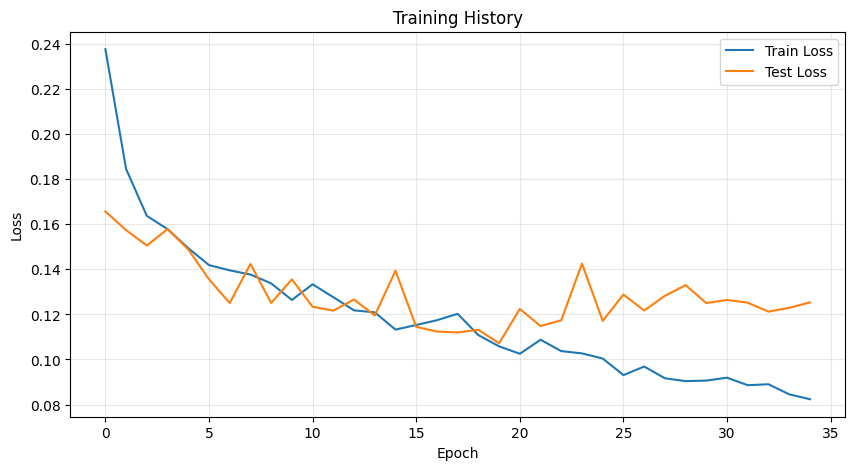

In [40]:

plt.figure(figsize=(10, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training History")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 9. Evaluation

In [51]:
def get_probs(model, loader):
    model.eval()
    y_true, y_prob = [], []
    with torch.no_grad():
        for x_num, x_cat, y_batch in loader:
            logits = model(x_num.to(device), x_cat.to(device))
            y_prob.extend(torch.sigmoid(logits).cpu().numpy())
            y_true.extend(y_batch.numpy())
    return np.array(y_true).astype(int), np.array(y_prob)

# 1) Cari threshold di VAL set
y_val_true, y_val_prob = get_probs(model, val_loader)

prec, rec, thr = precision_recall_curve(y_val_true, y_val_prob)

target_recall = 0.73   # margin di atas 0.70, karena recall test bisa turun dari val

# prec/rec punya 1 elemen lebih banyak dari thr, jadi buang elemen terakhir
prec, rec, thr = precision_recall_curve(y_val_true, y_val_prob)
prec_t, rec_t = prec[:-1], rec[:-1]

# Maksimalin nilai terkecil antara precision dan recall (titik paling seimbang)
balance = np.minimum(prec_t, rec_t)
best_idx = np.argmax(balance)

best_thr = thr[best_idx]
print(f"Best threshold: {best_thr:.4f} | Val precision: {prec_t[best_idx]:.3f} | Val recall: {rec_t[best_idx]:.3f}")

# 2) Pakai threshold itu di TEST set
y_true, y_prob = get_probs(model, test_loader)
y_pred = (y_prob >= best_thr).astype(int)

accuracy  = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall    = recall_score(y_true, y_pred, zero_division=0)
f1        = f1_score(y_true, y_pred, zero_division=0)
auc       = roc_auc_score(y_true, y_prob)
pr_auc    = average_precision_score(y_true, y_prob)

results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC", "PR-AUC"],
    "Value": [accuracy, precision, recall, f1, auc, pr_auc]
})
display(results)

Best threshold: 0.7250 | Val precision: 0.729 | Val recall: 0.729


,Metric,Value
0,Accuracy,0.985272
1,Precision,0.697479
2,Recall,0.751131
3,F1-Score,0.723312
4,ROC-AUC,0.987987
5,PR-AUC,0.724649


In [52]:

print(classification_report(
    y_true,
    y_pred,
    target_names=["Found", "Fell"],
    zero_division=0
))


              precision    recall  f1-score   support

       Found       0.99      0.99      0.99      8402
        Fell       0.70      0.75      0.72       221

    accuracy                           0.99      8623
   macro avg       0.85      0.87      0.86      8623
weighted avg       0.99      0.99      0.99      8623



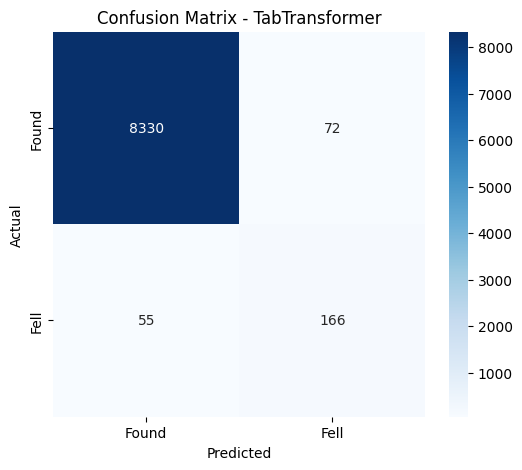

In [53]:

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Found", "Fell"],
    yticklabels=["Found", "Fell"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - TabTransformer")
plt.show()


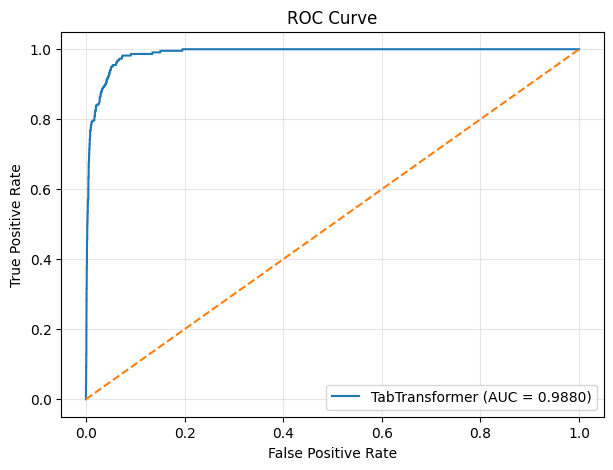

In [54]:

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_true, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"TabTransformer (AUC = {auc:.4f})")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()



## 10. Save Model

Model dapat disimpan untuk digunakan kembali.


In [55]:

torch.save({
    "model_state_dict": model.state_dict(),
    "numeric_cols": numeric_cols,
    "categorical_cols": categorical_cols,
    "category_maps": category_maps,
    "scaler": scaler,
    "num_imputer": num_imputer
}, "tabtransformer_nasa_meteorite.pth")

print("Model tersimpan sebagai: tabtransformer_nasa_meteorite.pth")


Model tersimpan sebagai: tabtransformer_nasa_meteorite.pth


# **UJI COBA METODE LAIN**

In [56]:
import time
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

SEEDS = [42, 7, 13, 21, 99]
EPOCHS, PATIENCE, BATCH = 100, 15, 64


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def make_splits(seed):
    X = data.drop(columns=["fall"])
    y = (data["fall"] == "Fell").astype(int)
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.20, random_state=seed, stratify=y)
    X_tr, X_va, y_tr, y_va = train_test_split(
        X_tr, y_tr, test_size=0.15, random_state=seed, stratify=y_tr)
    return X_tr, X_va, X_te, y_tr.values, y_va.values, y_te.values


def preprocess(X_tr, X_va, X_te):
    imp, sc = SimpleImputer(strategy="median"), StandardScaler()
    d = {
        "num_tr": sc.fit_transform(imp.fit_transform(X_tr[numeric_cols])),
    }
    d["num_va"] = sc.transform(imp.transform(X_va[numeric_cols]))
    d["num_te"] = sc.transform(imp.transform(X_te[numeric_cols]))

    def enc(s, m):
        return s.fillna("Unknown").astype(str).map(m).fillna(0).astype(int).values

    cat_tr, cat_va, cat_te, sizes = [], [], [], []
    for col in categorical_cols:
        tr = X_tr[col].fillna("Unknown").astype(str)
        mapping = {v: i + 1 for i, v in enumerate(sorted(tr.unique()))}
        sizes.append(len(mapping) + 1)
        cat_tr.append(enc(X_tr[col], mapping))
        cat_va.append(enc(X_va[col], mapping))
        cat_te.append(enc(X_te[col], mapping))
    d["cat_tr"] = np.column_stack(cat_tr)
    d["cat_va"] = np.column_stack(cat_va)
    d["cat_te"] = np.column_stack(cat_te)
    d["sizes"] = sizes
    return d


def pick_threshold(y_val, p_val):
    prec, rec, thr_ = precision_recall_curve(y_val, p_val)
    balance = np.minimum(prec[:-1], rec[:-1])
    return thr_[np.argmax(balance)]


def score(y_true, p, t):
    pred = (p >= t).astype(int)
    return {
        "Precision": precision_score(y_true, pred, zero_division=0),
        "Recall":    recall_score(y_true, pred, zero_division=0),
        "F1":        f1_score(y_true, pred, zero_division=0),
        "ROC_AUC":   roc_auc_score(y_true, p),
        "PR_AUC":    average_precision_score(y_true, p),
    }


def predict_probs(m, loader):
    m.eval()
    out = []
    with torch.no_grad():
        for xn, xc, _ in loader:
            out.append(torch.sigmoid(m(xn.to(device), xc.to(device))).cpu().numpy())
    return np.concatenate(out)


def eval_loss(m, loader, crit):
    m.eval()
    tot, n = 0.0, 0
    with torch.no_grad():
        for xn, xc, yb in loader:
            xn, xc, yb = xn.to(device), xc.to(device), yb.to(device)
            tot += crit(m(xn, xc), yb).item() * len(yb)
            n += len(yb)
    return tot / n


def run_tabtransformer(d, y_tr, y_va, y_te):
    # drop_last=True biar batch sisa berukuran 1 nggak bikin error di BatchNorm
    tr_loader = DataLoader(MeteoriteDataset(d["num_tr"], d["cat_tr"], y_tr),
                           batch_size=BATCH, shuffle=True, drop_last=True)
    va_loader = DataLoader(MeteoriteDataset(d["num_va"], d["cat_va"], y_va), batch_size=256)
    te_loader = DataLoader(MeteoriteDataset(d["num_te"], d["cat_te"], y_te), batch_size=256)

    m = TabTransformer(
        categories=d["sizes"], num_numeric=len(numeric_cols),
        dim=32, depth=3, heads=4, attn_dropout=0.30, ff_dropout=0.30
    ).to(device)

    pw = torch.tensor([np.sqrt((y_tr == 0).sum() / max((y_tr == 1).sum(), 1))],
                      dtype=torch.float32, device=device)
    crit = nn.BCEWithLogitsLoss(pos_weight=pw)
    opt = torch.optim.Adam(m.parameters(), lr=1e-3, weight_decay=1e-5)
    sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=3)

    best, best_state, wait = float("inf"), None, 0
    for ep in range(EPOCHS):
        m.train()
        for xn, xc, yb in tr_loader:
            xn, xc, yb = xn.to(device), xc.to(device), yb.to(device)
            opt.zero_grad()
            crit(m(xn, xc), yb).backward()
            torch.nn.utils.clip_grad_norm_(m.parameters(), max_norm=1.0)
            opt.step()
        vl = eval_loss(m, va_loader, crit)
        sch.step(vl)
        if vl < best:
            best, wait = vl, 0
            best_state = {k: v.detach().cpu().clone() for k, v in m.state_dict().items()}
        else:
            wait += 1
            if wait >= PATIENCE:
                break
    m.load_state_dict(best_state)
    return predict_probs(m, va_loader), predict_probs(m, te_loader)


def run_baselines(d, X_tr, X_va, X_te, y_tr, seed):
    ohe = OneHotEncoder(handle_unknown="ignore")
    c_tr = X_tr[categorical_cols].fillna("Unknown").astype(str)
    c_va = X_va[categorical_cols].fillna("Unknown").astype(str)
    c_te = X_te[categorical_cols].fillna("Unknown").astype(str)
    A_tr = np.hstack([d["num_tr"], ohe.fit_transform(c_tr).toarray()])
    A_va = np.hstack([d["num_va"], ohe.transform(c_va).toarray()])
    A_te = np.hstack([d["num_te"], ohe.transform(c_te).toarray()])

    models = {
        "LogisticRegression": LogisticRegression(max_iter=1000, class_weight="balanced"),
        "RandomForest": RandomForestClassifier(
            n_estimators=300, class_weight="balanced_subsample",
            n_jobs=-1, random_state=seed),
        "HistGradientBoosting": HistGradientBoostingClassifier(random_state=seed),
    }
    out = {}
    for name, clf in models.items():
        clf.fit(A_tr, y_tr)
        out[name] = (clf.predict_proba(A_va)[:, 1], clf.predict_proba(A_te)[:, 1])
    return out


# ================== MAIN LOOP ==================
rows = []
for seed in SEEDS:
    t0 = time.time()
    set_seed(seed)
    X_tr, X_va, X_te, y_tr, y_va, y_te = make_splits(seed)
    d = preprocess(X_tr, X_va, X_te)

    p_va, p_te = run_tabtransformer(d, y_tr, y_va, y_te)
    t = pick_threshold(y_va, p_va)
    rows.append({"Model": "TabTransformer", "Seed": seed, **score(y_te, p_te, t)})

    for name, (p_va, p_te) in run_baselines(d, X_tr, X_va, X_te, y_tr, seed).items():
        t = pick_threshold(y_va, p_va)
        rows.append({"Model": name, "Seed": seed, **score(y_te, p_te, t)})

    print(f"Seed {seed} selesai ({time.time() - t0:.0f} detik)")

# ================== RINGKASAN ==================
res = pd.DataFrame(rows)
cols = ["Precision", "Recall", "F1", "ROC_AUC", "PR_AUC"]
summary = res.groupby("Model")[cols].agg(["mean", "std"])
table = pd.DataFrame({
    c: summary[c]["mean"].map("{:.3f}".format) + " ± " + summary[c]["std"].map("{:.3f}".format)
    for c in cols
})
print("\nHasil kelas Fell (mean ± std, 5 seed):")
display(table)
display(res)

C:\Users\LEGION\AppData\Local\Temp\ipykernel_30896\3272952443.py:33: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)


Seed 42 selesai (113 detik)


C:\Users\LEGION\AppData\Local\Temp\ipykernel_30896\3272952443.py:33: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)


Seed 7 selesai (152 detik)


C:\Users\LEGION\AppData\Local\Temp\ipykernel_30896\3272952443.py:33: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)


...

Seed 21 selesai (167 detik)


C:\Users\LEGION\AppData\Local\Temp\ipykernel_30896\3272952443.py:33: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)


Seed 99 selesai (163 detik)

Hasil kelas Fell (mean ± std, 5 seed):


,Precision,Recall,F1,ROC_AUC,PR_AUC
Model,,,,,
HistGradientBoosting,0.776 ± 0.027,0.767 ± 0.031,0.771 ± 0.022,0.993 ± 0.002,0.835 ± 0.033
LogisticRegression,0.555 ± 0.019,0.547 ± 0.016,0.551 ± 0.015,0.979 ± 0.003,0.573 ± 0.024
RandomForest,0.800 ± 0.018,0.783 ± 0.031,0.791 ± 0.012,0.994 ± 0.002,0.847 ± 0.020
TabTransformer,0.730 ± 0.047,0.719 ± 0.026,0.724 ± 0.034,0.987 ± 0.003,0.761 ± 0.048


,Model,Seed,Precision,Recall,F1,ROC_AUC,PR_AUC
0,TabTransformer,42,0.649351,0.678733,0.663717,0.984759,0.686100
1,LogisticRegression,42,0.560386,0.524887,0.542056,0.979657,0.568606
2,RandomForest,42,0.782805,0.782805,0.782805,0.995387,0.840262
3,HistGradientBoosting,42,0.750000,0.787330,0.768212,0.993094,0.795238
4,TabTransformer,7,0.757009,0.733032,0.744828,0.986950,0.786779
5,LogisticRegression,7,0.535398,0.547511,0.541387,0.976434,0.563400
6,RandomForest,7,0.816038,0.782805,0.799076,0.993607,0.876142
7,HistGradientBoosting,7,0.779343,0.751131,0.764977,0.993072,0.857983
8,TabTransformer,13,0.730088,0.746606,0.738255,0.989475,0.786842
9,LogisticRegression,13,0.554054,0.556561,0.555305,0.980573,0.569004


In [57]:
class FTTransformer(nn.Module):
    def __init__(self, categories, num_numeric, dim=32, depth=3, heads=4, dropout=0.1):
        super().__init__()
        bound = 1 / np.sqrt(dim)
        self.num_weight = nn.Parameter(torch.empty(num_numeric, dim).uniform_(-bound, bound))
        self.num_bias = nn.Parameter(torch.zeros(num_numeric, dim))
        self.cat_emb = nn.ModuleList([nn.Embedding(n, dim) for n in categories])
        self.cls = nn.Parameter(torch.randn(1, 1, dim) * 0.02)

        layer = nn.TransformerEncoderLayer(
            d_model=dim, nhead=heads, dim_feedforward=dim * 4,
            dropout=dropout, activation="gelu",
            batch_first=True, norm_first=True
        )
        self.encoder = nn.TransformerEncoder(layer, num_layers=depth, enable_nested_tensor=False)
        self.head = nn.Sequential(nn.LayerNorm(dim), nn.ReLU(), nn.Linear(dim, 1))

    def forward(self, x_num, x_cat):
        tok_num = x_num.unsqueeze(-1) * self.num_weight + self.num_bias      # [B, n_num, dim]
        tok_cat = torch.stack([e(x_cat[:, i]) for i, e in enumerate(self.cat_emb)], dim=1)
        cls = self.cls.expand(x_num.size(0), -1, -1)
        x = self.encoder(torch.cat([cls, tok_num, tok_cat], dim=1))
        return self.head(x[:, 0]).squeeze(1)


def run_deep(d, y_tr, y_va, y_te, build_model):
    tr_loader = DataLoader(MeteoriteDataset(d["num_tr"], d["cat_tr"], y_tr),
                           batch_size=BATCH, shuffle=True, drop_last=True)
    va_loader = DataLoader(MeteoriteDataset(d["num_va"], d["cat_va"], y_va), batch_size=256)
    te_loader = DataLoader(MeteoriteDataset(d["num_te"], d["cat_te"], y_te), batch_size=256)

    m = build_model(d).to(device)
    pw = torch.tensor([np.sqrt((y_tr == 0).sum() / max((y_tr == 1).sum(), 1))],
                      dtype=torch.float32, device=device)
    crit = nn.BCEWithLogitsLoss(pos_weight=pw)
    opt = torch.optim.Adam(m.parameters(), lr=1e-3, weight_decay=1e-5)
    sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=3)

    best, best_state, wait = float("inf"), None, 0
    for ep in range(EPOCHS):
        m.train()
        for xn, xc, yb in tr_loader:
            xn, xc, yb = xn.to(device), xc.to(device), yb.to(device)
            opt.zero_grad()
            crit(m(xn, xc), yb).backward()
            torch.nn.utils.clip_grad_norm_(m.parameters(), max_norm=1.0)
            opt.step()
        vl = eval_loss(m, va_loader, crit)
        sch.step(vl)
        if vl < best:
            best, wait = vl, 0
            best_state = {k: v.detach().cpu().clone() for k, v in m.state_dict().items()}
        else:
            wait += 1
            if wait >= PATIENCE:
                break
    m.load_state_dict(best_state)
    return predict_probs(m, va_loader), predict_probs(m, te_loader)


# ================== LOOP FT-TRANSFORMER ==================
SEEDS_FT = SEEDS          # tes dulu pakai [42] kalau mau cek cepat
ft_rows = []

for seed in SEEDS_FT:
    t0 = time.time()
    set_seed(seed)
    X_tr, X_va, X_te, y_tr, y_va, y_te = make_splits(seed)
    d = preprocess(X_tr, X_va, X_te)

    p_va, p_te = run_deep(
        d, y_tr, y_va, y_te,
        lambda d: FTTransformer(d["sizes"], len(numeric_cols))
    )
    t = pick_threshold(y_va, p_va)
    ft_rows.append({"Model": "FTTransformer", "Seed": seed, **score(y_te, p_te, t)})
    print(f"Seed {seed} selesai ({time.time() - t0:.0f} detik)")

# ================== GABUNG DENGAN HASIL SEBELUMNYA ==================
res_all = pd.concat(
    [res[res["Model"] != "FTTransformer"], pd.DataFrame(ft_rows)],
    ignore_index=True
)
summary = res_all.groupby("Model")[cols].agg(["mean", "std"])
table_all = pd.DataFrame({
    c: summary[c]["mean"].map("{:.3f}".format) + " ± " + summary[c]["std"].map("{:.3f}".format)
    for c in cols
})
print("\nHasil kelas Fell (mean ± std):")
display(table_all)

Seed 42 selesai (85 detik)
Seed 7 selesai (117 detik)
Seed 13 selesai (114 detik)
Seed 21 selesai (117 detik)
Seed 99 selesai (71 detik)

Hasil kelas Fell (mean ± std):


,Precision,Recall,F1,ROC_AUC,PR_AUC
Model,,,,,
FTTransformer,0.746 ± 0.042,0.765 ± 0.034,0.755 ± 0.027,0.990 ± 0.002,0.779 ± 0.026
HistGradientBoosting,0.776 ± 0.027,0.767 ± 0.031,0.771 ± 0.022,0.993 ± 0.002,0.835 ± 0.033
LogisticRegression,0.555 ± 0.019,0.547 ± 0.016,0.551 ± 0.015,0.979 ± 0.003,0.573 ± 0.024
RandomForest,0.800 ± 0.018,0.783 ± 0.031,0.791 ± 0.012,0.994 ± 0.002,0.847 ± 0.020
TabTransformer,0.730 ± 0.047,0.719 ± 0.026,0.724 ± 0.034,0.987 ± 0.003,0.761 ± 0.048


# Kesimpulan

Penelitian ini menerapkan model *tabular Transformer*, yaitu TabTransformer dan FT-Transformer, untuk mengklasifikasikan status *Fell* dan *Found* pada dataset *Meteorite Landings*, lalu membandingkannya dengan *Logistic Regression*, *Random Forest*, dan *HistGradientBoosting*. Evaluasi dilakukan pada lima pembagian data acak berlapis (stratified) dengan ambang klasifikasi yang dipilih dari data validasi.

1. **Model *Transformer* mampu menangkap pola nonlinier pada data.** TabTransformer mencapai rata-rata F1 kelas *Fell* sebesar 0,724 (presisi 0,730 dan *recall* 0,719), jauh di atas *Logistic Regression* yang hanya mencapai 0,551.

2. **FT-Transformer lebih baik daripada TabTransformer.** Dengan memperlakukan setiap fitur numerik sebagai token, FT-Transformer meningkatkan rata-rata F1 menjadi 0,755, *recall* menjadi 0,765, dan PR-AUC menjadi 0,779 (dibandingkan 0,761 pada TabTransformer).

3. **Model berbasis pohon tetap menjadi acuan terkuat.** *Random Forest* memberikan hasil terbaik (F1 0,791 dan PR-AUC 0,847), diikuti *HistGradientBoosting* (F1 0,771 dan PR-AUC 0,835). Pada dataset tabular berukuran menengah dengan sedikit fitur ini, model *Transformer* belum mengungguli model pohon, meskipun selisih FT-Transformer relatif kecil, terutama pada *recall*.

4. **Pemilihan ambang pada data validasi diperlukan.** Kelas *Fell* hanya sekitar 2,6% dari seluruh data sehingga akurasi tidak informatif. Penyesuaian ambang menggunakan data validasi, bukan data uji, menjaga evaluasi bebas kebocoran dan menghasilkan keseimbangan presisi dan *recall* yang lebih baik.

5. **Hasil tidak seragam antar pembagian data.** Simpangan baku F1 pada model *Transformer* (0,027 sampai 0,034) lebih besar daripada *Random Forest* (0,012), sehingga hasil sebaiknya dilaporkan sebagai rata-rata dan simpangan baku dari beberapa pembagian data.

## Keterbatasan

Seluruh model memakai hiperparameter bawaan atau yang ditetapkan satu kali tanpa pencarian sistematis. Simpangan baku dihitung dari lima pembagian acak yang saling tumpang tindih sehingga cenderung terlalu optimistis dibandingkan validasi silang berlapis. Jumlah sampel *Fell* pada data uji relatif kecil (221), sehingga selisih beberapa prediksi dapat menggeser metrik beberapa poin persentase. Label *Fell/Found* juga mencerminkan cara meteorit ditemukan, sehingga fitur lokasi dan tahun dapat memuat pola program pencarian, bukan hanya sifat fisik meteorit.

## Saran

Penelitian selanjutnya dapat (1) melakukan pencarian hiperparameter sistematis untuk seluruh model, (2) memakai validasi silang berlapis dengan uji signifikansi antar model, (3) melakukan ablasi terkontrol untuk fitur turunan (indikator data hilang, transformasi logaritmik massa, fitur lokasi), dan (4) mengeksplorasi model *Transformer* tabular lain seperti SAINT.